In [3]:

import pandas as pd

df = pd.read_csv("fifa21_raw_data.csv", low_memory=False)

print(df.head())

                                           photoUrl  \
0  https://cdn.sofifa.com/players/158/023/21_60.png   
1  https://cdn.sofifa.com/players/020/801/21_60.png   
2  https://cdn.sofifa.com/players/200/389/21_60.png   
3  https://cdn.sofifa.com/players/192/985/21_60.png   
4  https://cdn.sofifa.com/players/190/871/21_60.png   

                       LongName  \
0                  Lionel Messi   
1  C. Ronaldo dos Santos Aveiro   
2                     Jan Oblak   
3               Kevin De Bruyne   
4    Neymar da Silva Santos Jr.   

                                           playerUrl Nationality Positions  \
0  http://sofifa.com/player/158023/lionel-messi/2...   Argentina  RW ST CF   
1  http://sofifa.com/player/20801/c-ronaldo-dos-s...    Portugal     ST LW   
2  http://sofifa.com/player/200389/jan-oblak/210005/    Slovenia        GK   
3  http://sofifa.com/player/192985/kevin-de-bruyn...     Belgium    CAM CM   
4  http://sofifa.com/player/190871/neymar-da-silv...      Brazil    

## Data Cleaning

In [4]:
selected_columns = [
    'Name',
    'Age',
    'Nationality',
    'Positions',
    '↓OVA',
    'POT',
    'PAC',
    'SHO',
    'PAS',
    'DRI'
]

df = df[selected_columns]

print(df.head())
print(df.shape)

                Name  Age Nationality Positions  ↓OVA  POT  PAC  SHO  PAS  DRI
0           L. Messi   33   Argentina  RW ST CF    93   93   85   92   91   95
1  Cristiano Ronaldo   35    Portugal     ST LW    92   92   89   93   81   89
2           J. Oblak   27    Slovenia        GK    91   93   87   92   78   90
3       K. De Bruyne   29     Belgium    CAM CM    91   91   76   86   93   88
4          Neymar Jr   28      Brazil    LW CAM    91   91   91   85   86   94
(18979, 10)


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         18979 non-null  object
 1   Age          18979 non-null  int64 
 2   Nationality  18979 non-null  object
 3   Positions    18979 non-null  object
 4   ↓OVA         18979 non-null  int64 
 5   POT          18979 non-null  int64 
 6   PAC          18979 non-null  int64 
 7   SHO          18979 non-null  int64 
 8   PAS          18979 non-null  int64 
 9   DRI          18979 non-null  int64 
dtypes: int64(7), object(3)
memory usage: 1.4+ MB
None


### DataShape

In [6]:
print("Rows, Columns:", df.shape)

Rows, Columns: (18979, 10)


### Missing Values

In [7]:
df.isnull().sum()

Name           0
Age            0
Nationality    0
Positions      0
↓OVA           0
POT            0
PAC            0
SHO            0
PAS            0
DRI            0
dtype: int64

### Duplicate Rows

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1


In [9]:
print(df.dtypes)

Name           object
Age             int64
Nationality    object
Positions      object
↓OVA            int64
POT             int64
PAC             int64
SHO             int64
PAS             int64
DRI             int64
dtype: object


In [10]:
df = df.drop_duplicates()

In [11]:
print(df.duplicated().sum())

0


In [12]:
print(df.dtypes)

Name           object
Age             int64
Nationality    object
Positions      object
↓OVA            int64
POT             int64
PAC             int64
SHO             int64
PAS             int64
DRI             int64
dtype: object


In [13]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].nunique())


Name
17919

Age
29

Nationality
164

Positions
640

↓OVA
47

POT
48

PAC
70

SHO
78

PAS
68

DRI
69


In [14]:
string_cols = ['Name', 'Nationality', 'Positions']

for col in string_cols:
    df[col] = df[col].str.strip()

In [15]:
df.describe()

,Age,↓OVA,POT,PAC,SHO,PAS,DRI
count,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000
mean,25.194225,65.718042,71.135789,67.453683,53.457582,57.680472,62.874750
std,4.710618,6.968701,6.114189,10.678065,13.827581,10.081845,9.927607
min,16.000000,47.000000,47.000000,25.000000,16.000000,25.000000,25.000000
25%,21.000000,61.000000,67.000000,61.000000,44.000000,51.000000,57.000000
50%,25.000000,66.000000,71.000000,68.000000,56.000000,58.000000,64.000000
75%,29.000000,70.000000,75.000000,75.000000,64.000000,64.000000,69.000000
max,53.000000,93.000000,95.000000,96.000000,93.000000,93.000000,95.000000


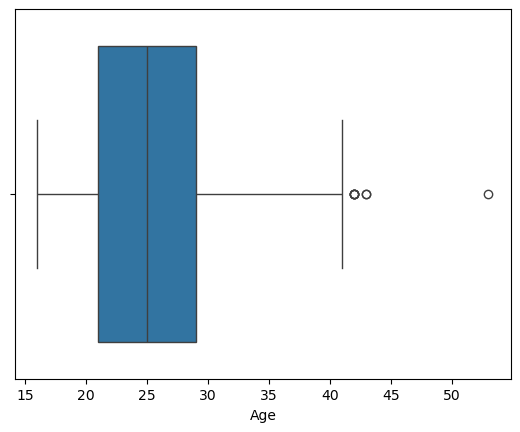

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Age'])
plt.show()

In [17]:
df.isnull().sum()

Name           0
Age            0
Nationality    0
Positions      0
↓OVA           0
POT            0
PAC            0
SHO            0
PAS            0
DRI            0
dtype: int64

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18978 entries, 0 to 18978
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         18978 non-null  object
 1   Age          18978 non-null  int64 
 2   Nationality  18978 non-null  object
 3   Positions    18978 non-null  object
 4   ↓OVA         18978 non-null  int64 
 5   POT          18978 non-null  int64 
 6   PAC          18978 non-null  int64 
 7   SHO          18978 non-null  int64 
 8   PAS          18978 non-null  int64 
 9   DRI          18978 non-null  int64 
dtypes: int64(7), object(3)
memory usage: 1.6+ MB


In [19]:
df.isnull().sum()

Name           0
Age            0
Nationality    0
Positions      0
↓OVA           0
POT            0
PAC            0
SHO            0
PAS            0
DRI            0
dtype: int64

In [20]:
df.to_csv("fifa21_cleaned.csv", index=False)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18978 entries, 0 to 18978
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         18978 non-null  object
 1   Age          18978 non-null  int64 
 2   Nationality  18978 non-null  object
 3   Positions    18978 non-null  object
 4   ↓OVA         18978 non-null  int64 
 5   POT          18978 non-null  int64 
 6   PAC          18978 non-null  int64 
 7   SHO          18978 non-null  int64 
 8   PAS          18978 non-null  int64 
 9   DRI          18978 non-null  int64 
dtypes: int64(7), object(3)
memory usage: 1.6+ MB


In [22]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [23]:
print(df['Age'].min())
print(df['Age'].max())

16
53


In [24]:
print(df['↓OVA'].min())
print(df['↓OVA'].max())

47
93


In [25]:
df.rename(columns={'↓OVA':'Overall_Rating'}, inplace=True)

In [26]:
df.to_csv("fifa21_cleaned.csv", index=False)

In [29]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Age'] >= lower) & (df['Age'] <= upper)]

print(df.shape)

(18970, 10)


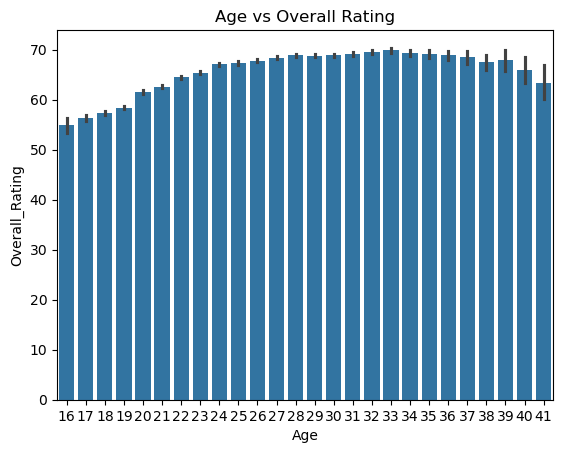

                     Age  Overall_Rating
Age             1.000000        0.467567
Overall_Rating  0.467567        1.000000


In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



sns.barplot(x='Age', y='Overall_Rating', data=df)
plt.title('Age vs Overall Rating')
plt.show()

print(df[['Age', 'Overall_Rating']].corr())

In [28]:
print(df.columns)

Index(['Name', 'Age', 'Nationality', 'Positions', 'Overall_Rating', 'POT',
       'PAC', 'SHO', 'PAS', 'DRI'],
      dtype='object')


## Correlation Matrix

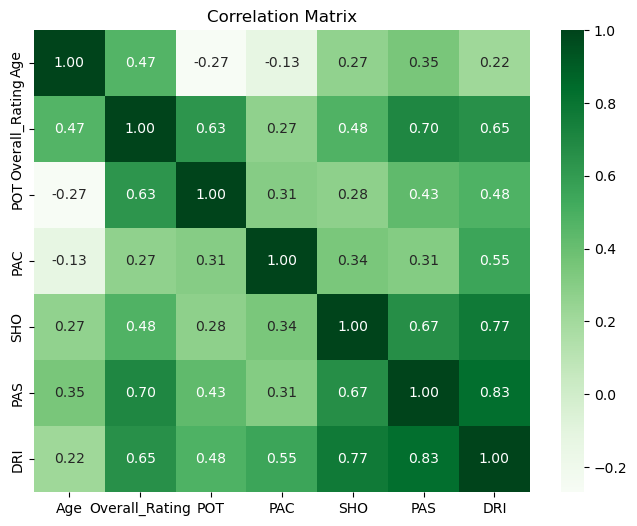

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['Age', 'Overall_Rating', 'POT', 'PAC', 'SHO', 'PAS', 'DRI']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='Greens', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Pair Plot

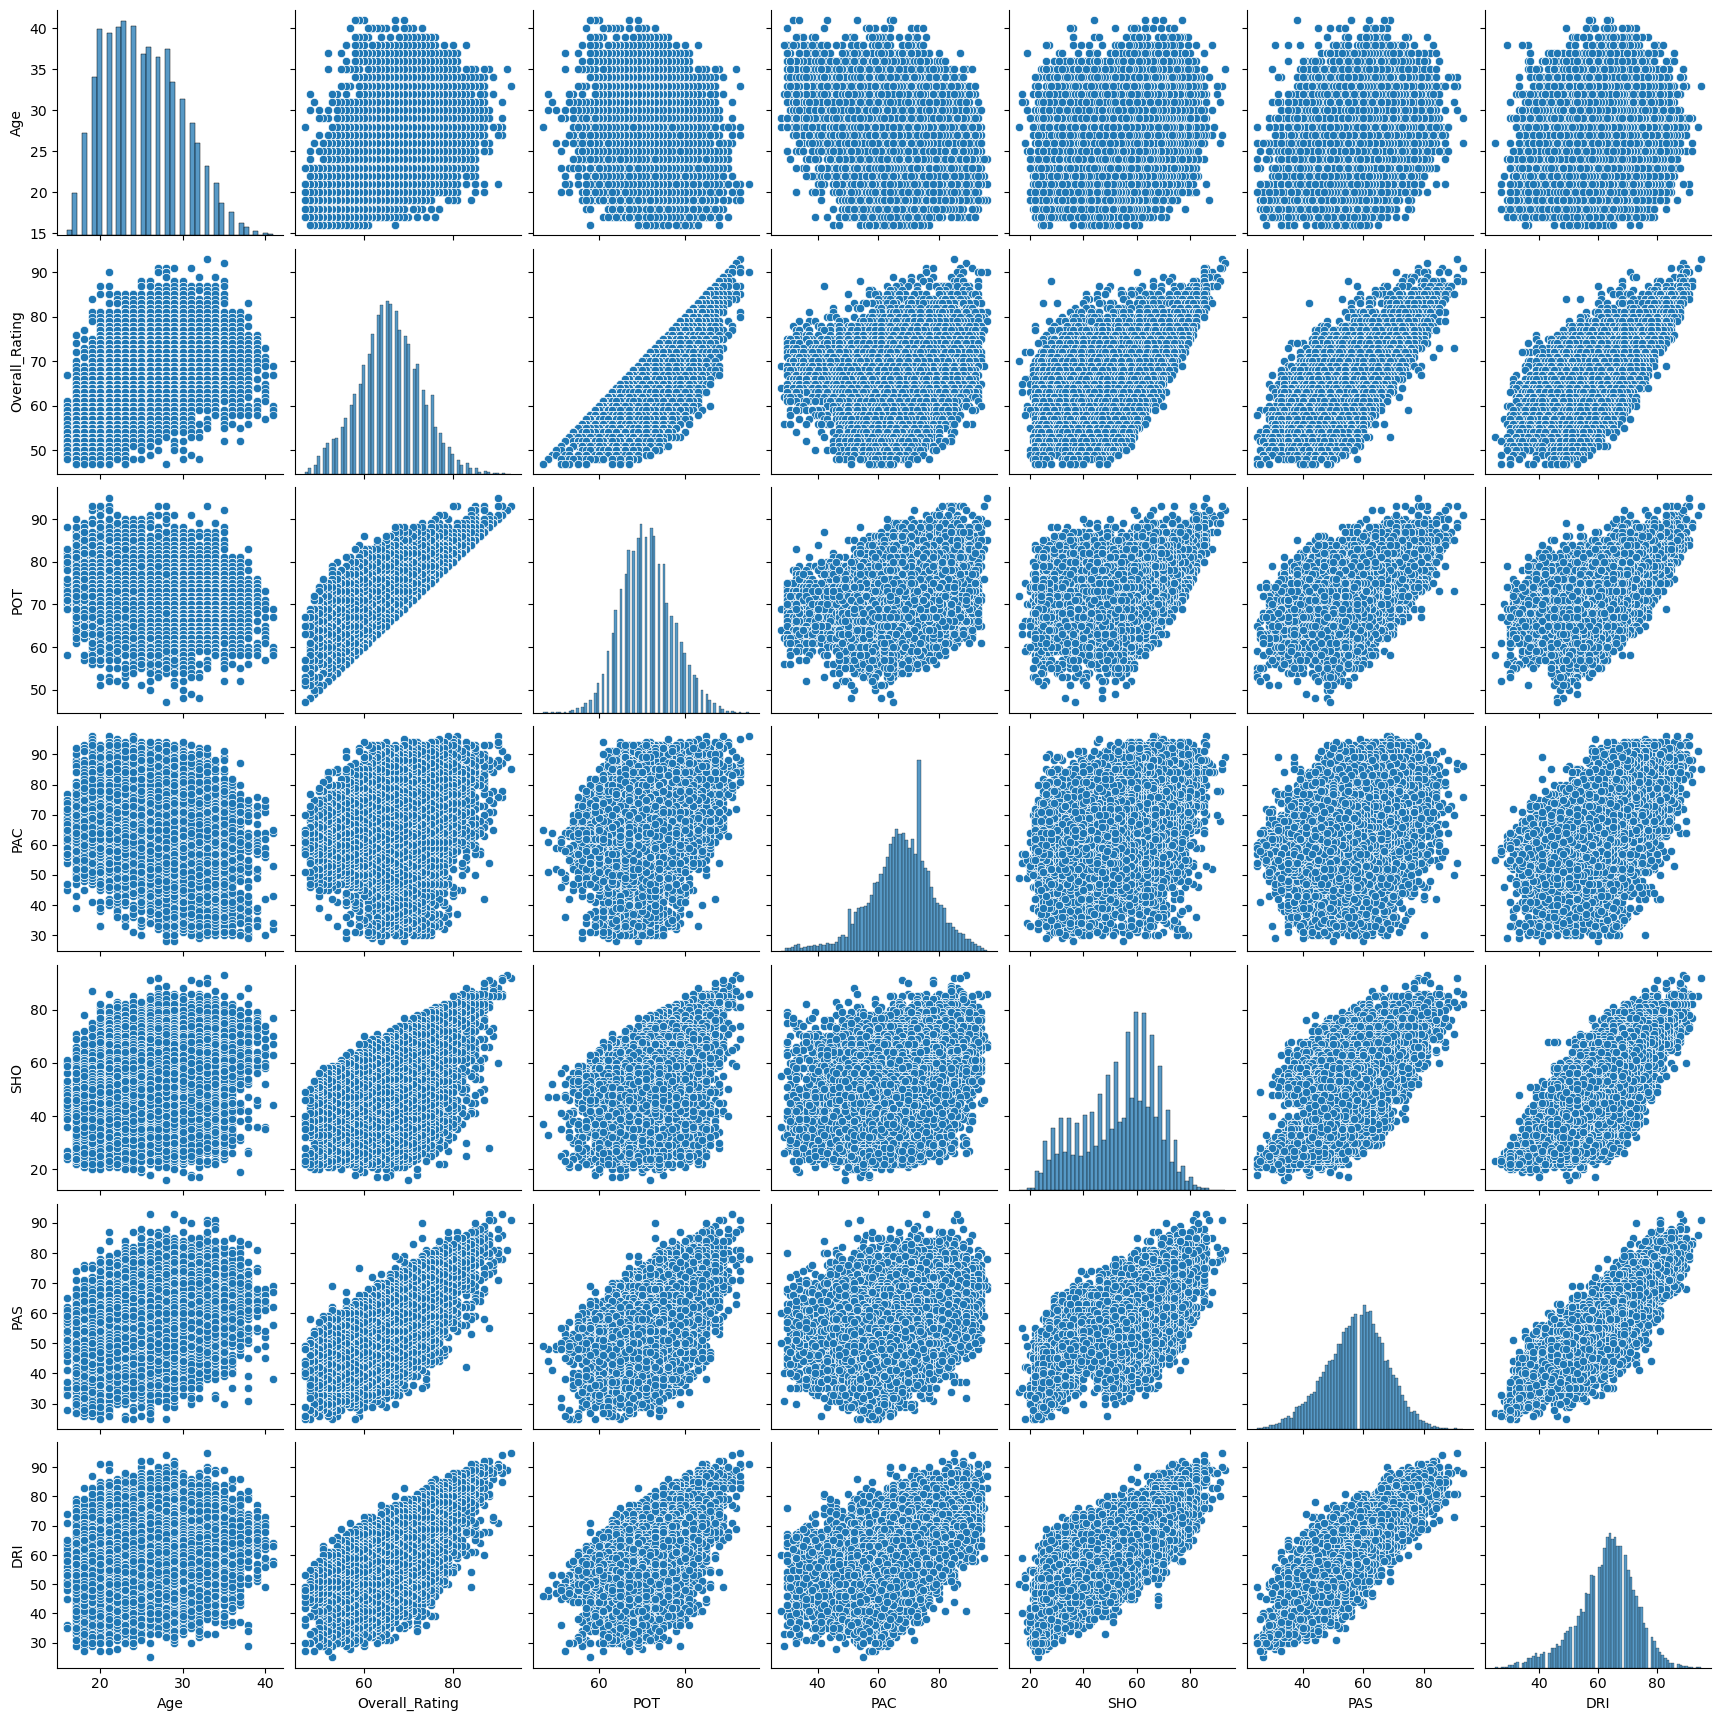

In [36]:
cols = ['Age', 'Overall_Rating', 'POT', 'PAC', 'SHO', 'PAS', 'DRI']

sns.pairplot(df[cols])
plt.show()

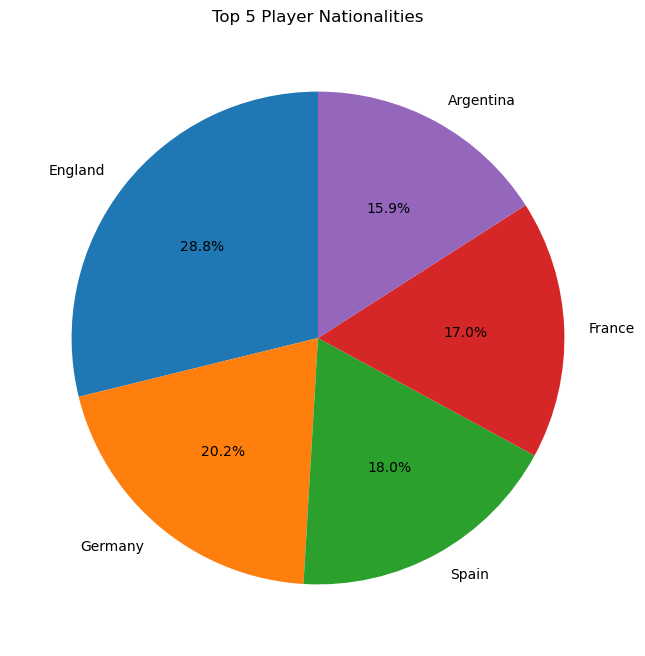

In [37]:
import matplotlib.pyplot as plt

top_nations = df['Nationality'].value_counts().head(5)

plt.figure(figsize=(8,8))
plt.pie(
    top_nations,
    labels=top_nations.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Top 5 Player Nationalities')
plt.show()

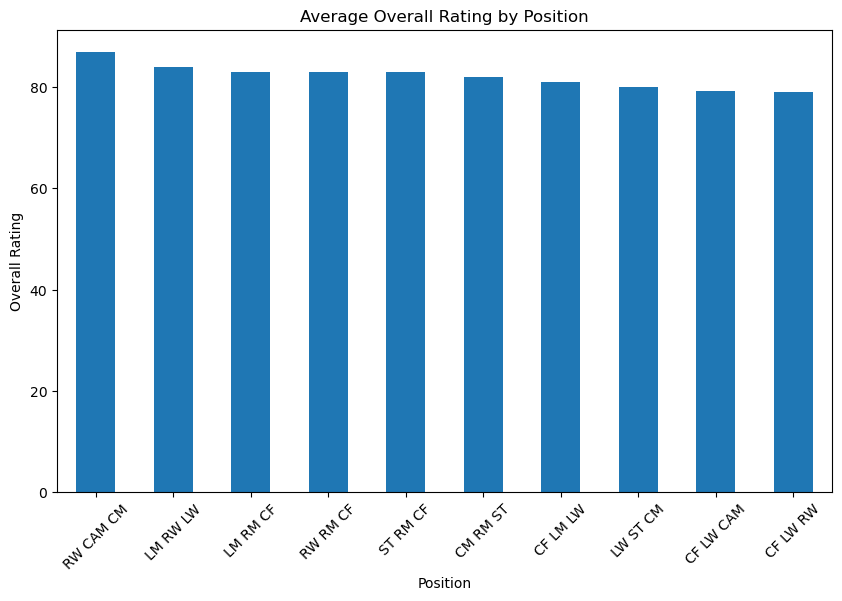

In [38]:
import matplotlib.pyplot as plt

avg_rating = df.groupby('Positions')['Overall_Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
avg_rating.plot(kind='bar')

plt.title('Average Overall Rating by Position')
plt.xlabel('Position')
plt.ylabel('Overall Rating')
plt.xticks(rotation=45)
plt.show()

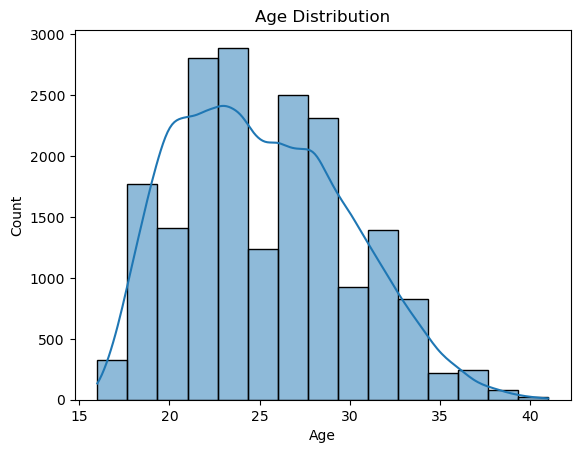

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Age'], bins=15, kde=True)
plt.title('Age Distribution')
plt.show()

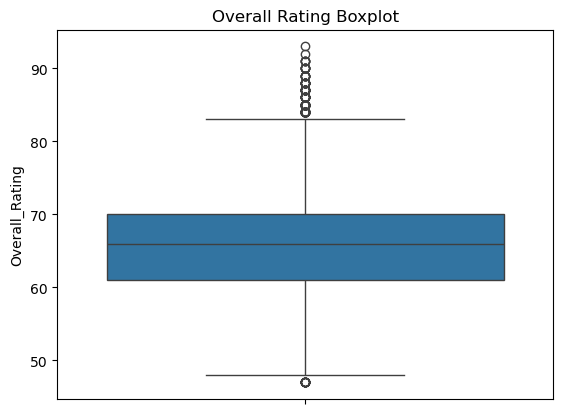

In [40]:
sns.boxplot(y=df['Overall_Rating'])
plt.title('Overall Rating Boxplot')
plt.show()